In [1]:
import os
from pathlib import Path
import sys

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")

import matplotlib.pyplot as plt
import numpy as np
from rich.console import Console
from rich.table import Table

cwd = Path.cwd().resolve()
PROJECT_ROOT = cwd if (cwd / "tdmd").exists() else cwd.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import jax.numpy as jnp

from tdmd import FFTTransform, tdmdii
from examples.plasma_flow import draw_frame, make_plasma, relative_error, reconstruct_tdmdii_sequence

plt.style.use("ggplot")

In [2]:
Z, t = make_plasma(nx=96, ny=96, nt=128)
train_tensor = jnp.transpose(Z[:, :, :96], (0, 2, 1))
pred_idx = train_tensor.shape[1]

In [3]:
X = train_tensor[:, :-1, :]
Y = train_tensor[:, 1:, :]
transform = FFTTransform()
gamma = 0.999
signvals_threshold = 1.0e-8

modes, schur_tensor, amplitudes, multirank = tdmdii(
    X,
    Y,
    transform,
    gamma=gamma,
    signvals_threshold=signvals_threshold,
)
pred_steps = np.arange(pred_idx + 1)
pred_sequence = reconstruct_tdmdii_sequence(modes, schur_tensor, amplitudes, pred_idx, transform)
true_sequence = jnp.stack([Z[:, :, step] for step in pred_steps])
state_errors = np.asarray([relative_error(true_sequence[step], pred_sequence[step]) for step in pred_steps])
snapshot_pred = pred_sequence[pred_idx]
snapshot_true = true_sequence[pred_idx]
snapshot_re = float(state_errors[pred_idx])

table = Table(title="Plasma TDMDII")
table.add_column("Name", no_wrap=True)
table.add_column("Value")
table.add_row("sequence shape", f"{tuple(Z.shape)}")
table.add_row("k_max", f"{int(multirank.max())}")
table.add_row("sum k_j", f"{int(multirank.sum())}")
table.add_row("mean state-wise RE", f"{state_errors.mean():.4e}")
table.add_row("max state-wise RE", f"{state_errors.max():.4e}")
table.add_row("snapshot RE @ t={pred_idx}", f"{snapshot_re:.4e}")
Console().print(table)

                Plasma TDMDII                 
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Name                       ┃ Value         ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequence shape             │ (96, 96, 128) │
│ k_max                      │ 5             │
│ sum k_j                    │ 224           │
│ mean state-wise RE         │ 4.3941e-02    │
│ max state-wise RE          │ 5.8479e-02    │
│ snapshot RE @ t={pred_idx} │ 5.8479e-02    │
└────────────────────────────┴───────────────┘

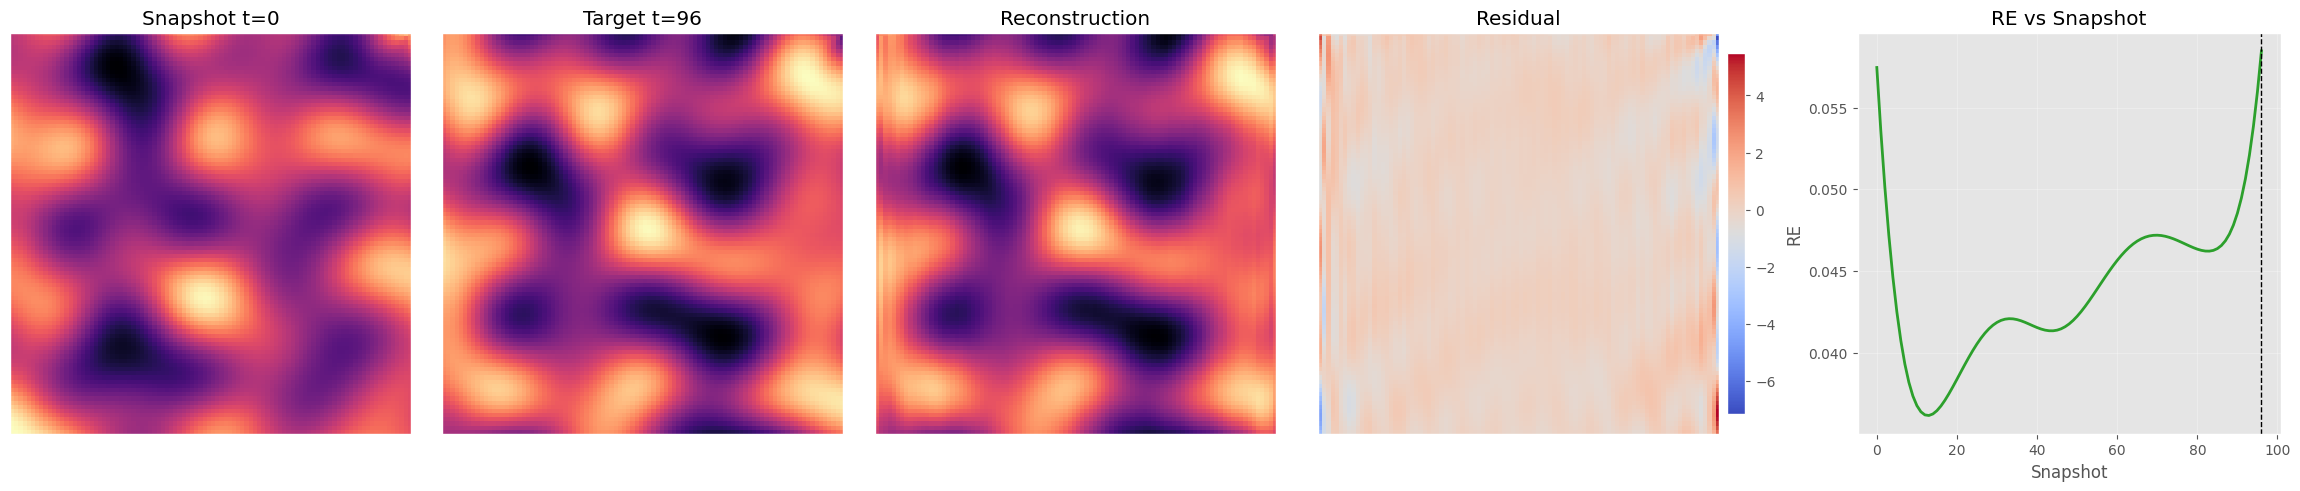

In [4]:
fig, axes = plt.subplots(1, 5, figsize=(23, 4.8), constrained_layout=True)

draw_frame(axes[0], Z[:, :, 0], "Snapshot t=0")
draw_frame(axes[1], snapshot_true, f"Target t={pred_idx}")
draw_frame(axes[2], snapshot_pred, "Reconstruction")

residual_img = draw_frame(axes[3], snapshot_true - snapshot_pred, "Residual", cmap="coolwarm")
fig.colorbar(residual_img, ax=axes[3], shrink=0.9, pad=0.02)
axes[4].plot(pred_steps, state_errors, linewidth=2, color="tab:green")
axes[4].axvline(pred_idx, color="black", linestyle="--", linewidth=1)
axes[4].set_title("RE vs Snapshot")
axes[4].set_xlabel("Snapshot")
axes[4].set_ylabel("RE")
axes[4].grid(True, alpha=0.3)

plt.show();